Visualizing: crop_preview.png


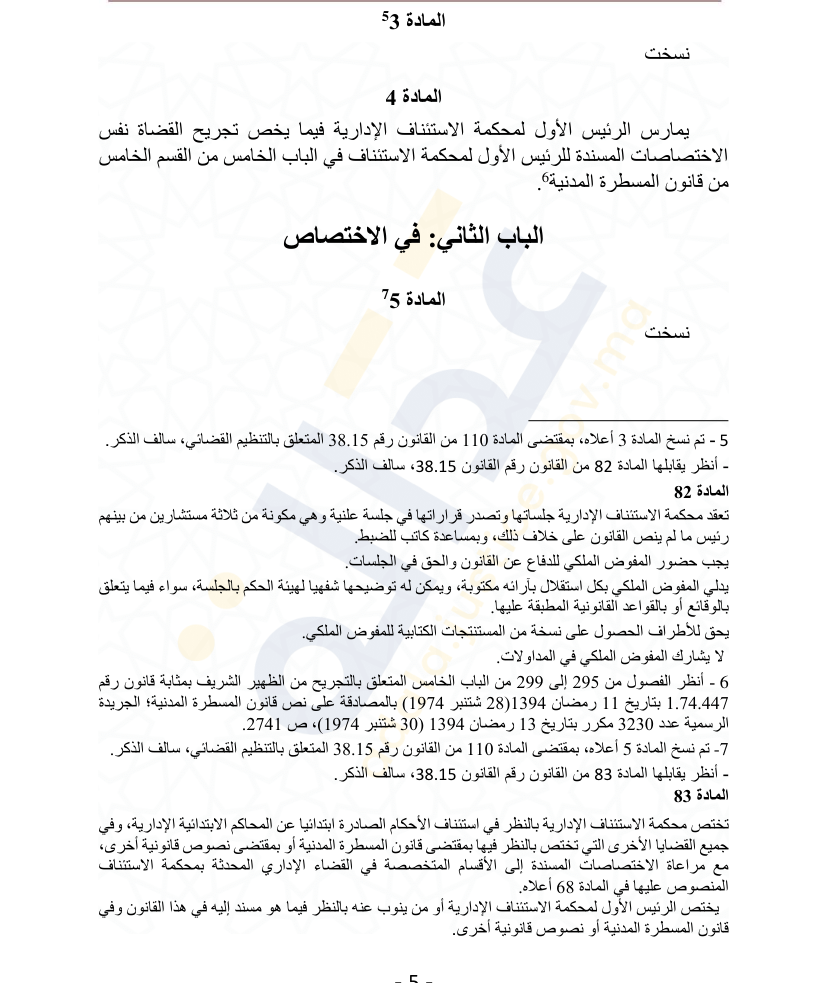

In [23]:
import ollama
import re
from IPython.display import Image, display

# Show the image we are testing
image_path = "crop_preview.png"
print("Visualizing:", image_path)
display(Image(filename=image_path))

In [ ]:
# 1. Load image bytes
with open(image_path, "rb") as f:
    img_bytes = f.read()

print("\nCalling Ollama deepseek-ocr... (Streaming)")
stream = ollama.generate(
    model="deepseek-ocr:latest",
    prompt="<|grounding|>Convert the document to text.",
    images=[img_bytes],
    stream=True,
    options={
        "temperature": 0,
        "num_predict": 2048,
    },
)

print("\n--- 1. RAW OLLAMA OUTPUT ---")
raw_text = ""
for chunk in stream:
    text_chunk = chunk.get("response", "")
    print(text_chunk, end="", flush=True)
    raw_text += text_chunk
print()


# 2. Clean grounding tags logic
def clean_deepseek_output(text: str) -> str:
    text = re.sub(r"<\|ref\|>.*?<\|/ref\|>", "", text)
    text = re.sub(r"<\|det\|>.*?<\|/det\|>", "", text)
    text = re.sub(r"<\|.*?\|>", "", text)
    return text.strip()


cleaned_text = clean_deepseek_output(raw_text)
print("\n--- 2. CLEANED OUTPUT ---")
print(cleaned_text)

# 3. Table HTML to RAG logic (imported directly from the library)
try:
    from pdf2text_arabic._tables import html_to_rag_text

    rag_text = html_to_rag_text(cleaned_text)
    print("\n--- 3. RAG CONVERTED OUTPUT ---")
    print(rag_text)
except Exception as e:
    print("\n--- RAG CONVERSION FAILED ---")
    print(e)

---

### LM Studio Test

Testing the exact same surgical crop with a model running in LM Studio via the OpenAI API.


In [12]:
import base64
from openai import OpenAI

# Ensure LM Studio is running and the local server is started (usually on port 1234)
client = OpenAI(base_url="http://localhost:1234/v1", api_key="lm-studio")


def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")


base64_image = encode_image(image_path)

print("Calling LM Studio model...")
try:
    response = client.chat.completions.create(
        model="local-model",  # LM Studio uses whatever model is currently loaded
        messages=[
            {
                "role": "user",
                "content": [
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/png;base64,{base64_image}",
                        },
                    },
                ],
            }
        ],
        temperature=0.0,
    )

    print("\n--- LM STUDIO OUTPUT ---")
    print(response.choices[0].message.content)
except Exception as e:
    print(f"\nError connecting to LM Studio: {e}")
    print(
        "Make sure LM Studio is running, a vision model is loaded, and the local server is started on port 1234."
    )

Calling LM Studio model...

--- LM STUDIO OUTPUT ---
|   |   |   |
|---|---|---|
| **1** | **2** | **3** |

1. أن السهلة قد تمت معاينتها وفقاً لاحكام اللائحة 7 من الباب الاول للدقاقية.
2. وانه تبين من المعاينة:
   1- أن السهلة تلبي متطلبات الاتفاقية بالنسبة لما يلي:
    1- الهيكل، والآلات الرئيسية والساعدة، والمراجل وأوعية المنشط الاخرى؛
    2- ترتيبات وتواصيل التقسيمات الداخلية الكثيفة؛
    3- خطوط التحميل التالية للتقسيم الداخلي:
    |   |   |
    |---|---|
    | **1** | **2** |
    | **3** | **4** |

1. خطوط تحميل التقسيم الداخلي المحددة:
   1. والموضوع على جانب السهلة عند
   2. من الباب الثاني (1)
   3. من الباب الثالث (1)
   4. من الباب الرابع (1)

1. أن السهلة تلبي متطلبات الاتفاقية فيما يتعلق بالوقاية الهيكلية من الحرائق، ونظم واجهة السلامة الحركية، وخطط مكافحة الحرائق؛
2- أن جهزة ومعدات الانفاذ في قوارب وأطراف النجاة، وزوارق الانفاذ قد وفّرت وفقاً لمتطلبات الاتفاقية؛
3- أن السهلة زودت باجهزة قذف الحبال والمنشآت اللاسلكية المستخدمة في جهزة الانفاذ وفقاً لمتطلبات الاتفاقية؛
4- أن

---

### Google Gemini 1.5 Flash Test

Testing the exact same surgical crop with Google Gemini 1.5 Flash.


In [24]:
import os
from dotenv import load_dotenv

load_dotenv()  # loads GEMINI_API_KEY from .env

True

In [26]:
from google import genai
import PIL.Image
import os

api_key = os.environ.get("GEMINI_API_KEY")
if not api_key:
    raise ValueError("Set GEMINI_API_KEY in the cell above before running this.")

client = genai.Client(api_key=api_key)

image_path = "crop_preview.png"
img = PIL.Image.open(image_path)

print("Calling Google Gemini 3 Flash Preview...")
try:
    response = client.models.generate_content(
        model="gemini-3-flash-preview",
        contents=[
            """You are an expert OCR system specialized in extracting complex official Arabic documents, including legal, technical, and administrative records. Extract all Arabic text exactly as it appears without translating or summarizing. Do not auto-correct spelling.

CRITICAL TABLE INSTRUCTIONS:
Do NOT use standard Markdown table formatting (do not use the | pipe character). Instead, extract every table by representing each row as a vertical block separated by ---. Map the column header to the cell value exactly like this:
EXCLUSIONS:
Strictly ignore and DO NOT extract any footnotes at the bottom of the page. You must also ignore and remove any superscript footnote markers (e.g., ¹, ², ³) embedded within the main text. Ignore all page headers, page numbers, and stamps. Only extract the core body content.
---
Header 1: [Cell Value]
Header 2: [Cell Value]
Header 3: [Cell Value]
---

If a cell is empty, do not include that line. Do not generate completely empty table rows.""",
            img,
        ],
    )

    print("\n--- GEMINI 3 FLASH OUTPUT ---")
    print(response.text)
except Exception as e:
    print(f"\nError connecting to Gemini: {e}")

Calling Google Gemini 3 Flash Preview...

--- GEMINI 3 FLASH OUTPUT ---
المادة 3
نسخت

المادة 4
يمارس الرئيس الأول لمحكمة الاستئناف الإدارية فيما يخص تجريح القضاة نفس الاختصاصات المسندة للرئيس الأول لمحكمة الاستئناف في الباب الخامس من القسم الخامس من قانون المسطرة المدنية.

الباب الثاني: في الاختصاص

المادة 5
نسخت
